## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    print(f'Percentage of duplicates: {duplicate_count / len(df) * 100:.2f}%')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape after dropping duplicates: {df.shape}')
else:
    print('Dataset is clean, no duplicates found.')

Number of duplicate rows: 0
Dataset is clean, no duplicates found.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Numerical Features Insights:

* **`longitude` / `latitude`**:
    * These features represent the geographical coordinates of the centroid for a specific area (likely a block group or residential neighborhood).
    * A standard deviation (`std`) of ~2, combined with the large difference between the `min` and `max` values (approx. 10 degrees), indicates that the analyzed areas are spread across a vast geographic surface, covering an entire state rather than just a single city or neighboring towns.

* **`housing_median_age`**:
    * Represents the median age of the houses in a specific location. The median is used instead of the arithmetic mean because it is robust and not sensitive to outliers.
    * The dataset includes highly diverse neighborhoods, ranging from newly built (1 year) to older ones (capped at 52 years), with the overall median age being around ~30 years.

* **`total_rooms`**:
    * Represents the total number of rooms across all housing units in a given area (block group).
    * The data ranges from areas with very few rooms (e.g., isolated or mountainous regions) to metropolitan zones reaching up to 39,000+ rooms. Because the `mean > median`, we can conclude that the `total_rooms` feature has a right-skewed distribution (Positive Skew).

* **`total_bedrooms` / `population`**:
    * Represent the total number of bedrooms and the total number of inhabitants within the area specified by the coordinates.
    * Similar to `total_rooms`, the conclusions are identical: these features also exhibit a positive skew, meaning a few highly dense outliers push the average up.

* **`households`**:
    * Represents the total number of households (groups of people living together in the same unit) within a specific area.

* **`median_income`**:
    * The cumulative annual income of a household, scaled down for easier data processing (e.g., a value of 1.5 represents $15,000 per year). It is capped at 15.0001 (approx. $150,000).
    * This shows that the data captures a highly diverse population across California at the time of the census, reflecting various social classes and socioeconomic backgrounds (from disadvantaged communities to luxury neighborhoods).

* **`median_house_value`**:
    * This is the target variable (the most important column for our goal), which we will need to predict using a regression model. It represents the median price/value of a home in a given area.


In [5]:

# See how many values are missing in every column
# df.isnull().sum()

# See the procentage of how many data are missing from a column
df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

* Overall, the dataset is clean, except for the `total_bedrooms` column, which contains 207 `null` values. 
* **Crucial distinction:** A `null` value does not mean there are "zero bedrooms" (if it were a purely commercial zone, the value would be recorded as `0`). It simply means the data is missing (e.g., lost during collection or unrecorded).
* **Next steps:** Since 207 rows represent exactly **1%** of the dataset (20,640 entries), we have two safe strategies to handle this later:
    1.  **Drop the rows:** Acceptable, as the data loss is minimal.
    2.  **Fill with the median (Imputation):** The recommended best practice. This allows us to keep the other valuable features (income, location, age) of those 207 areas intact.


### Is the missingness in `total_bedrooms` random or biased?

Before deciding *drop vs impute*, we compare the rows where `total_bedrooms` is missing against the rest. If the two groups look statistically similar, median imputation is safe. If they differ (e.g. missing rows come mostly from one region or income bracket), imputation would inject bias.


In [6]:
# Mean of each numeric column, split by whether total_bedrooms is missing
mask = df['total_bedrooms'].isna()

compare = pd.DataFrame({
    'missing_rows': df[mask].mean(numeric_only=True),
    'present_rows': df[~mask].mean(numeric_only=True),
})
compare['diff_%'] = ((compare['missing_rows'] - compare['present_rows'])
                     / compare['present_rows'] * 100).round(2)
compare.round(2)

,missing_rows,present_rows,diff_%
longitude,-119.47,-119.57,-0.08
latitude,35.50,35.63,-0.38
housing_median_age,29.27,28.63,2.23
total_rooms,2562.60,2636.50,-2.80
total_bedrooms,NaN,537.87,NaN
population,1477.77,1424.95,3.71
households,510.02,499.43,2.12
median_income,3.82,3.87,-1.26
median_house_value,206007.28,206864.41,-0.41


In [7]:
# Missing rate broken down by ocean_proximity
(df['total_bedrooms'].isna()
   .groupby(df['ocean_proximity'])
   .mean() * 100).round(2).rename('missing_pct')

ocean_proximity
<1H OCEAN     1.12
INLAND        0.84
ISLAND        0.00
NEAR BAY      0.87
NEAR OCEAN    1.13
Name: missing_pct, dtype: float64

### Verdict on the missing rows

Every column differs by less than ~4% between the missing-rows group and the present-rows group (most under 1%). Geography, income, price and household size are all statistically indistinguishable. There is no hidden bias driving the missingness.

**Decision:** we impute `total_bedrooms` with its median. We keep all 20,640 rows and don't lose the useful features (income, location, age) of the 207 affected areas.


In [8]:
# Impute the 207 missing values with the median
bedrooms_median = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(bedrooms_median)

print(f'Imputed with median = {bedrooms_median}')
print(f'Remaining nulls in total_bedrooms: {df["total_bedrooms"].isna().sum()}')

Imputed with median = 435.0
Remaining nulls in total_bedrooms: 0


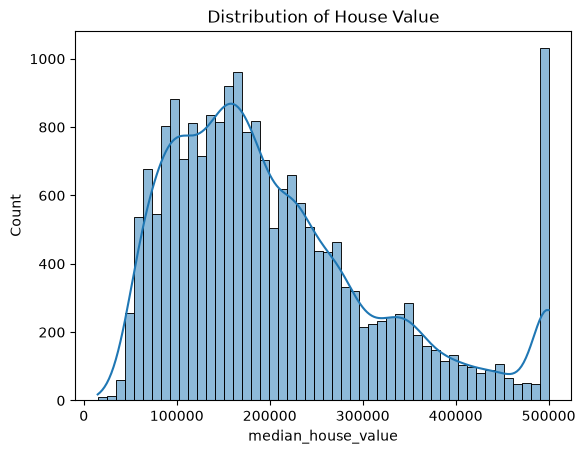

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of House Value')
plt.show()

## Conclusion :

Observing the histogram, most values are concentrated in the 50000 - 250000 range, but the right tail unnaturally explodes at the 500000 mark. This massive spike represents artificially capped data, meaning any house worth more than this limit was simply recorded as the maximum value. Applying a log transformation will not solve this problem, as the artificial cluster will merely shift to a different scale. If we keep these capped values, it will negatively affect the model during training, because the coefficients will be tempted to learn these artificial limits, distorting the predictions for regular houses. A proper treatment for this issue is to completely drop the examples that hit this capped threshold, sacrificing a small percentage of data to ensure the model learns a clean and accurate relationship for the rest of the homes.


### How much data would we lose if we drop the caps?

Both `median_house_value` (at 500001) and `housing_median_age` (at 52) show artificial caps. Before we commit to dropping, let's see exactly what share of the dataset that removes.


In [10]:
total = len(df)

price_cap_mask = df['median_house_value'] >= 500001
age_cap_mask   = df['housing_median_age'] >= 52
both_mask      = price_cap_mask | age_cap_mask

print(f'Rows at price cap (>=500001):  {price_cap_mask.sum():>5}  ({price_cap_mask.mean()*100:.2f}%)')
print(f'Rows at age cap  (>=52 years): {age_cap_mask.sum():>5}  ({age_cap_mask.mean()*100:.2f}%)')
print(f'Rows lost if we drop BOTH:     {both_mask.sum():>5}  ({both_mask.mean()*100:.2f}%)')

Rows at price cap (>=500001):    965  (4.68%)
Rows at age cap  (>=52 years):  1273  (6.17%)
Rows lost if we drop BOTH:      2068  (10.02%)


### What to drop and what to keep

* **Price cap (4.68%) — drop.** Non-negotiable. If we keep these ~965 rows the model learns that "expensive" literally means the number 500001, which destroys predictions for genuinely high-value homes.
* **Age cap (6.17%) — keep.** `housing_median_age` is a weak predictor to begin with (correlation with price is low and, as the earlier scatter showed, geography dominates it). Throwing away another 6% of the dataset for a mediocre feature is a bad trade. Tree-based models will simply learn that "52" is a bucket; linear models can bin the column later if needed.

So the actual data loss going into modeling is **~4.68%**, not 10%.


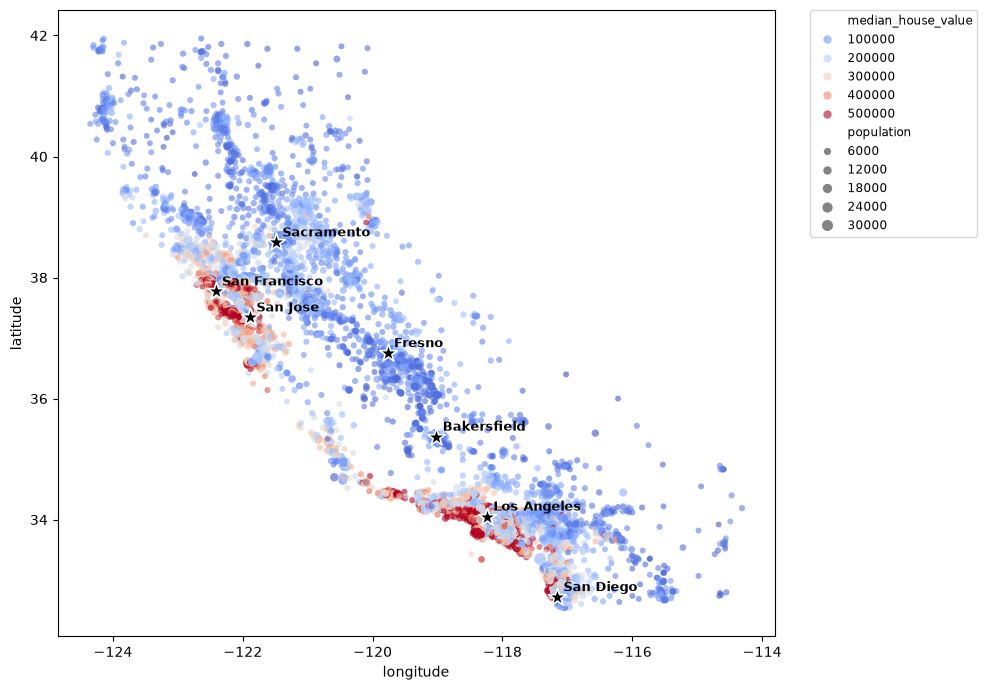

In [11]:
plt.figure(figsize=(10, 7))

base_scatter = sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    size='population',
    palette='coolwarm',
    alpha=0.6,
    linewidth=0         
)

major_cities = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
    'Fresno':        (-119.77, 36.75),
    'Sacramento':    (-121.49, 38.58),
    'Bakersfield':   (-119.02, 35.37),
}

for city, (lon, lat) in major_cities.items():
    base_scatter.axes.scatter(lon, lat, marker='*', s=180,
                              color='black', edgecolor='white',
                              linewidth=1.2, zorder=5)
    base_scatter.axes.text(lon + 0.1, lat + 0.1, city, fontsize=9,
                           fontweight='bold', color='black', zorder=6)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize='small',         
    title_fontsize='medium'
)

plt.tight_layout()
plt.show()

## Conclusion:

This scatter plot acts as a geographical map of the block group centroids across California. Overlaying the major cities on top of the price/population heatmap makes one pattern extremely clear: **big city + coast = expensive**.

* **The coast-city combo drives the red clusters:** The densest red areas line up almost perfectly with the coastal metropolitan hubs — the Bay Area (San Francisco / San Jose) in the north and the Los Angeles / San Diego region in the south. Being *near the ocean* alone is not enough; the price spike appears where the coast overlaps with a major urban center.
* **Inland cities are not enough on their own:** Sacramento, Fresno, and Bakersfield are all large cities, but they sit in a sea of blue. This proves that urban size by itself does not push prices up — the ocean multiplier is missing.
* **Empty coast is not enough either:** The coastline north of the Bay Area is right on the ocean, yet prices stay pale blue. Without a nearby metropolitan hub, coastal proximity alone barely moves the needle.
* **Feature engineering opportunity:** Since the true signal comes from the *interaction* between "close to a major city" and "close to the coast", it makes sense to engineer new features later — for example, distance to the nearest major city (LA, SF, San Diego, San Jose), or a combined "coastal-metro" score. These should carry much more predictive power than raw longitude / latitude alone.


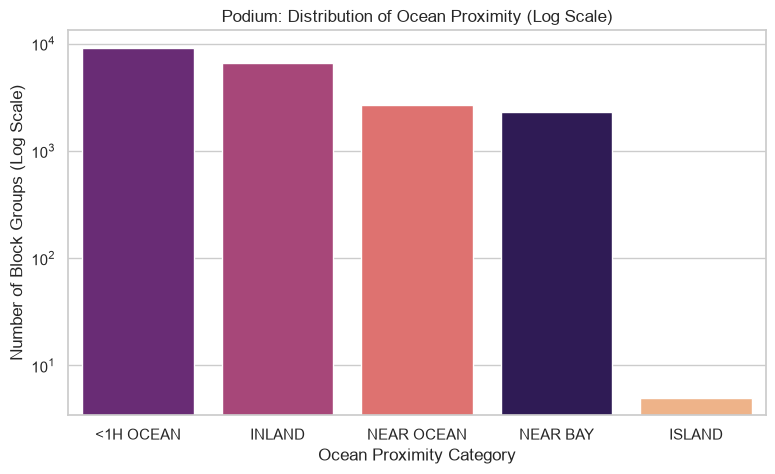

In [12]:
# Extract the categories sorted by their frequency
podium_order = df['ocean_proximity'].value_counts().index

# Set up the visual space
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Create the count plot
sns.countplot(
    data=df, 
    x='ocean_proximity', 
    order=podium_order,
    hue='ocean_proximity',
    palette='magma',
    legend=False
)

# Set the Y-axis to a logarithmic scale
plt.yscale('log')

# Add titles and labels
plt.title('Podium: Distribution of Ocean Proximity (Log Scale)')
plt.xlabel('Ocean Proximity Category')
plt.ylabel('Number of Block Groups (Log Scale)')

# Display the plot
plt.show()


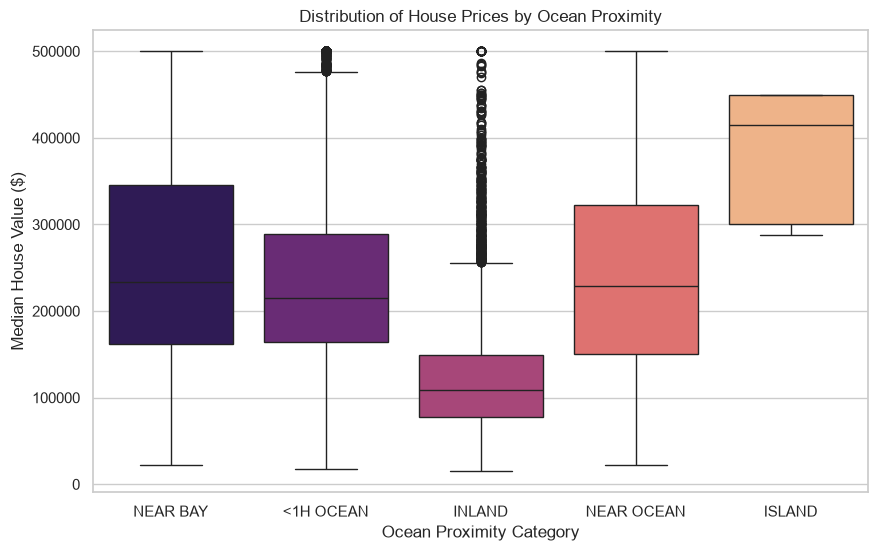

In [13]:

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a boxplot to compare the distribution of prices across categories
sns.boxplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    hue='ocean_proximity',
    palette='magma',
    legend=False
)

# Add titles and labels
plt.title('Distribution of House Prices by Ocean Proximity')
plt.xlabel('Ocean Proximity Category')
plt.ylabel('Median House Value ($)')

# Display the plot
plt.show()

## Conclusion: 

* **ISLAND:** There are very few examples, but they hold the highest baseline prices. The model will easily learn this strong relationship: being located on an island significantly increases a district's property value.
* **<1H OCEAN:** The vast majority of block groups fall into this category, typically ranging between $150,000 and $250,000. However, a significant number of examples migrate heavily toward the $500,000 mark. As seen on the scatter map, these tend to be districts located in large coastal cities.
* **INLAND:** Prices drop drastically here, but we observe natural outliers (wealthy neighborhoods, industrial zones). We keep these to teach the model that natural high-value exceptions exist even in cheaper areas.
* **NEAR BAY & NEAR OCEAN:** These represent naturally affluent, solid neighborhoods. The price distribution here is high but consistent and natural, without any abnormal artificial spikes.


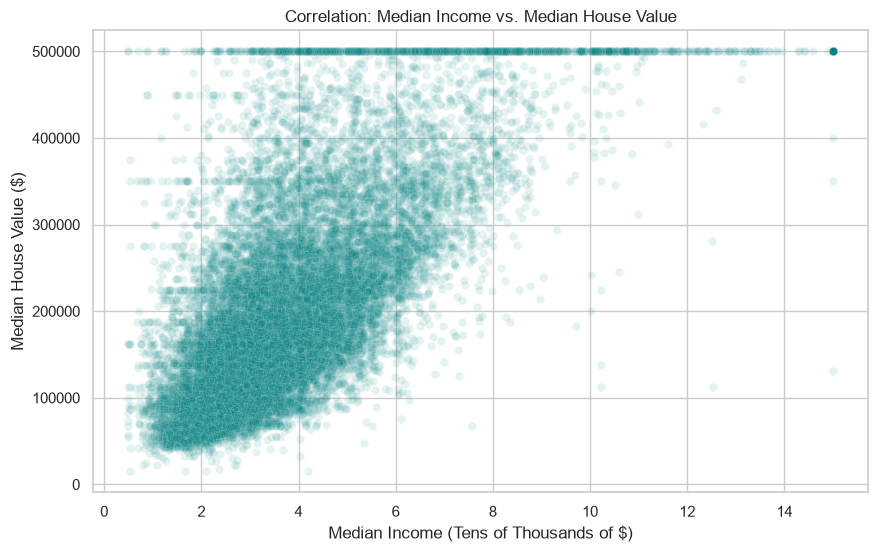

In [14]:
# Set the visual space
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the scatter plot with transparency to handle overplotting
sns.scatterplot(
    data=df, 
    x='median_income', 
    y='median_house_value', 
    alpha=0.1,         # Low alpha is crucial here to see density 
    color='teal'
)

# Add titles and labels
plt.title('Correlation: Median Income vs. Median House Value')
plt.xlabel('Median Income (Tens of Thousands of $)')
plt.ylabel('Median House Value ($)')

# Display the plot
plt.show()

## Conclusion: 

* **Population Density vs. Price:** The visual density of expensive homes in the 4.0 to 8.0 income bracket is primarily a reflection of population distribution. This range holds the vast majority of the population, resulting in a wide vertical spread of house values from very low to the maximum cap.
* **The Artificial Cap Effect (Income > 8.5):** In the higher income brackets (8.5 and above), the data heavily clusters along the absolute top line. This occurs because the true market value of homes for these high earners overwhelmingly exceeds the $500,000 census limit, forcing the majority of these data points to flatline at the artificial ceiling. 
* **Strong Positive Correlation:** The overall scatter plot displays a clear upward trend. The "floor" of the data point cloud rises steadily as income increases, confirming that `median_income` is a highly reliable predictor of `median_house_value`.
* **Data Collection Artifacts:** Below the massive $500,000 cap, faint horizontal lines are visible across the plot (e.g., around $450,000 and $350,000). These straight lines indicate artificial clustering caused by rounding estimates during the data collection process.


### Crowding (people per household) × income → house value

Two intuitions we want to check together:
* **Wealthy areas** = fewer people per home (large houses, few occupants per unit).
* **Poor / dense areas** = many people per household (shared units, crowding).

If the price signal really sits at the intersection of *high income + low crowding*, the scatter should show the reddest points concentrated in that corner.


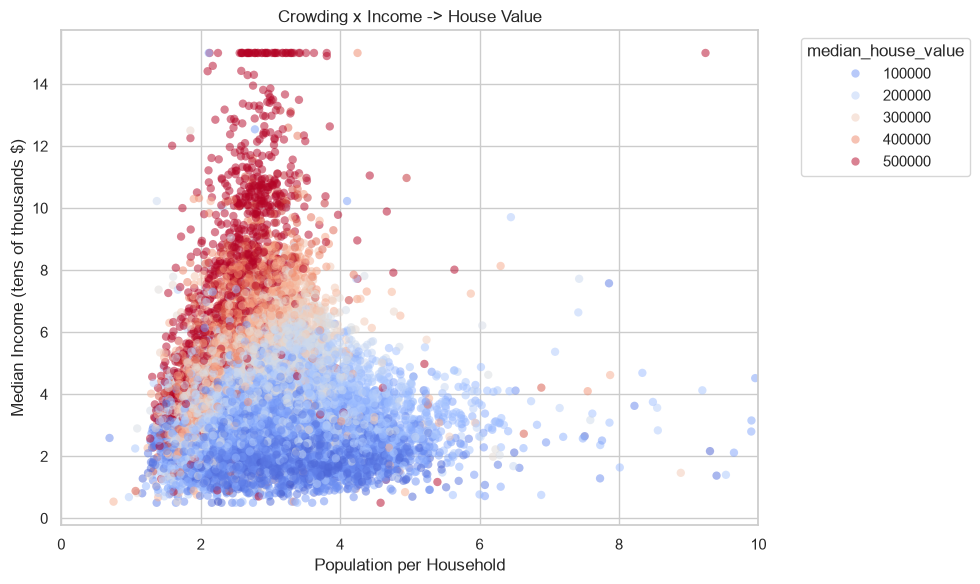

In [ ]:
df['population_per_household'] = df['population'] / df['households']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='population_per_household',
    y='median_income',
    hue='median_house_value',
    palette='coolwarm',
    alpha=0.5,
    linewidth=0
)

plt.xlim(0, 10)

plt.title('Crowding x Income -> House Value')
plt.xlabel('Population per Household')
plt.ylabel('Median Income (tens of thousands $)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='median_house_value')
plt.tight_layout()
plt.show()

### What we see

The red cloud (expensive homes, 400k+) sits clearly in the upper-left corner: **low crowding (2 - 3.5 people per household) combined with high income (7+)**. As we move right (more crowded homes) the color shifts to blue almost regardless of income — density penalizes price.

The horizontal red line at the very top is the artificial income cap at 15 (== $150k), same phenomenon we already spotted on the price histogram.


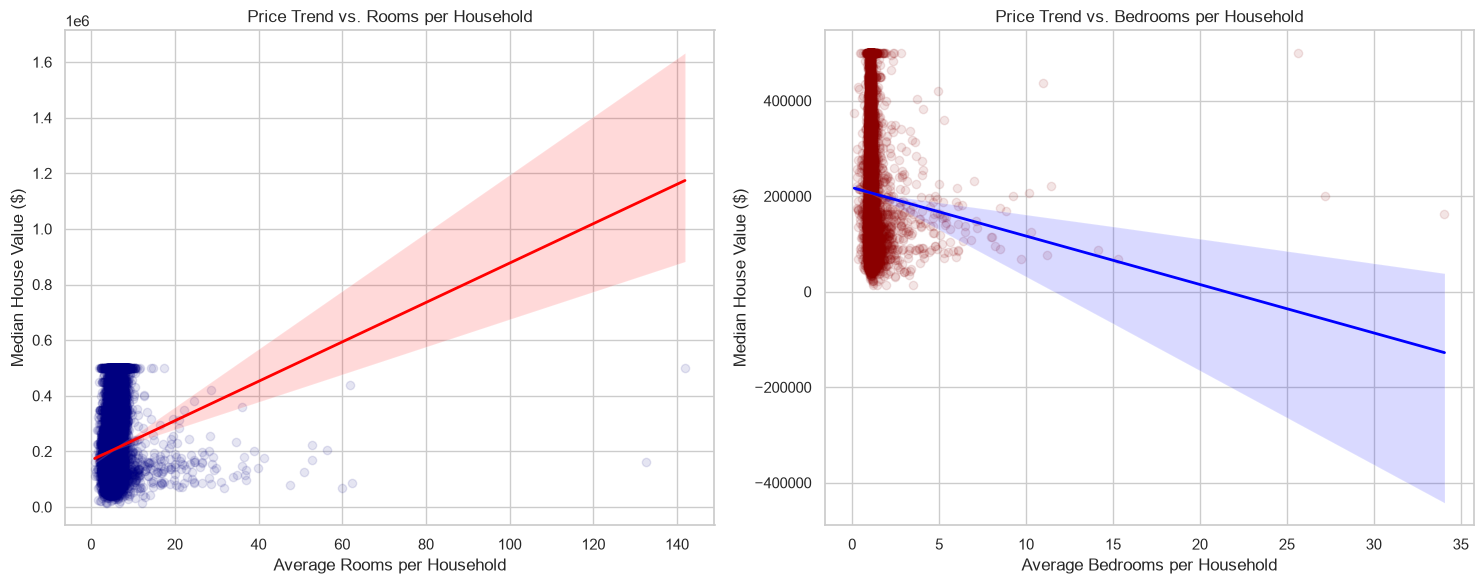

In [16]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_household'] = df['total_bedrooms'] / df['households']

# 2. Set up the figure space (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Price vs. Rooms per Household
sns.regplot(
    data=df, 
    x='rooms_per_household', 
    y='median_house_value', 
    ax=axes[0],
    scatter_kws={'alpha': 0.1, 'color': 'navy'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title('Price Trend vs. Rooms per Household')
axes[0].set_xlabel('Average Rooms per Household')
axes[0].set_ylabel('Median House Value ($)')

# Plot 2: Price vs. Bedrooms per Household
sns.regplot(
    data=df, 
    x='bedrooms_per_household', 
    y='median_house_value', 
    ax=axes[1],
    scatter_kws={'alpha': 0.1, 'color': 'darkred'}, 
    line_kws={'color': 'blue', 'linewidth': 2}
)
axes[1].set_title('Price Trend vs. Bedrooms per Household')
axes[1].set_xlabel('Average Bedrooms per Household')
axes[1].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()


## Conclusion:

* Data points showing 30 to 140 bedrooms per "household" are not massive family mansions. These are clear data collection quirks—likely commercial properties, hotels, or resorts that were misclassified as single residential units. They do not represent the standard housing market.
* Because these hotel-like anomalies have a surprisingly low median price compared to their massive size, they act as a heavy weight on the right side of the regression plot. They drag the entire right end of the trend line downward, forcing the slope to become negative.
* Garbage In, Garbage Out. The regression algorithm is purely mathematical; it doesn't know that house prices cannot drop below zero. Because the line was dragged into a negative slope, extending it further results in impossible predictions (e.g., predicting a price of -$200,000 for a large estate). If we feed the model this corrupted data, it will output corrupted logic.
* This visualization acts as definitive proof that we cannot train our model on raw data. It is absolutely critical to clean these specific features—either by capping them at a logical threshold (e.g., maximum 10-15 rooms) or dropping the commercial anomalies entirely—so the algorithm can learn the true, positive correlation between property size and value.


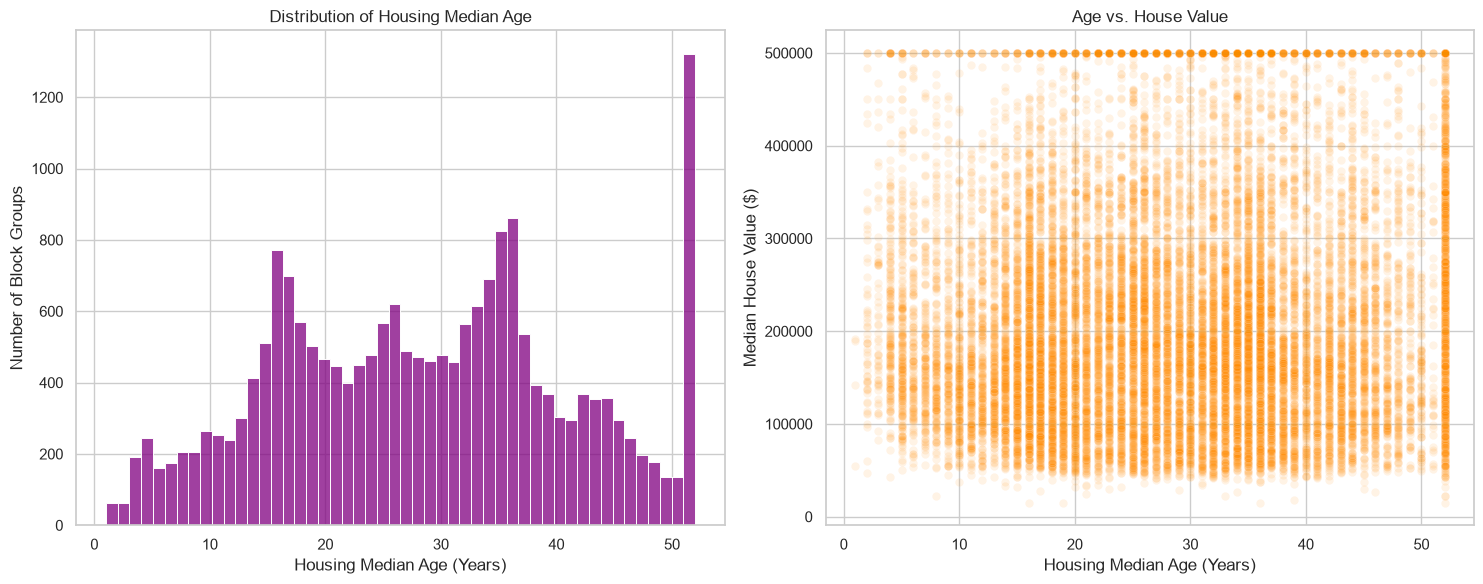

In [17]:
# Set up the figure space with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Histogram to reveal the distribution and the artificial cap at 52 years
sns.histplot(
    data=df, 
    x='housing_median_age', 
    bins=50, 
    color='purple', 
    ax=axes[0]
)
axes[0].set_title('Distribution of Housing Median Age')
axes[0].set_xlabel('Housing Median Age (Years)')
axes[0].set_ylabel('Number of Block Groups')

# Plot 2: Scatter plot to analyze the relationship between Age and Price
sns.scatterplot(
    data=df, 
    x='housing_median_age', 
    y='median_house_value', 
    alpha=0.1, 
    color='darkorange',
    ax=axes[1]
)
axes[1].set_title('Age vs. House Value')
axes[1].set_xlabel('Housing Median Age (Years)')
axes[1].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()


## Conclusion: 

* Looking at the distribution, there are surprisingly few brand-new neighborhoods. Furthermore, the scatter plot clearly shows that these young houses have absolutely no price advantage. A 5-year-old property is just as likely (if not more likely) to be cheaper than a 50-year-old one. 
* Why doesn't new mean expensive? Because all the premium land (coastlines, city centers) was built on decades ago. The newer homes are pushed further inland where space is available but land values are drastically lower. Geography completely overrides the age of the building.
* Just like the price column, the age column has its own artificial cap. Any neighborhood older than 52 years was lazily clumped together into a massive single spike at the end of the histogram.
* Because of this artificial data cap and the fact that a house's age is easily defeated by its geographic location, `housing_median_age` is just too noisy. It will not be a strong, determining factor for our model to predict market value.


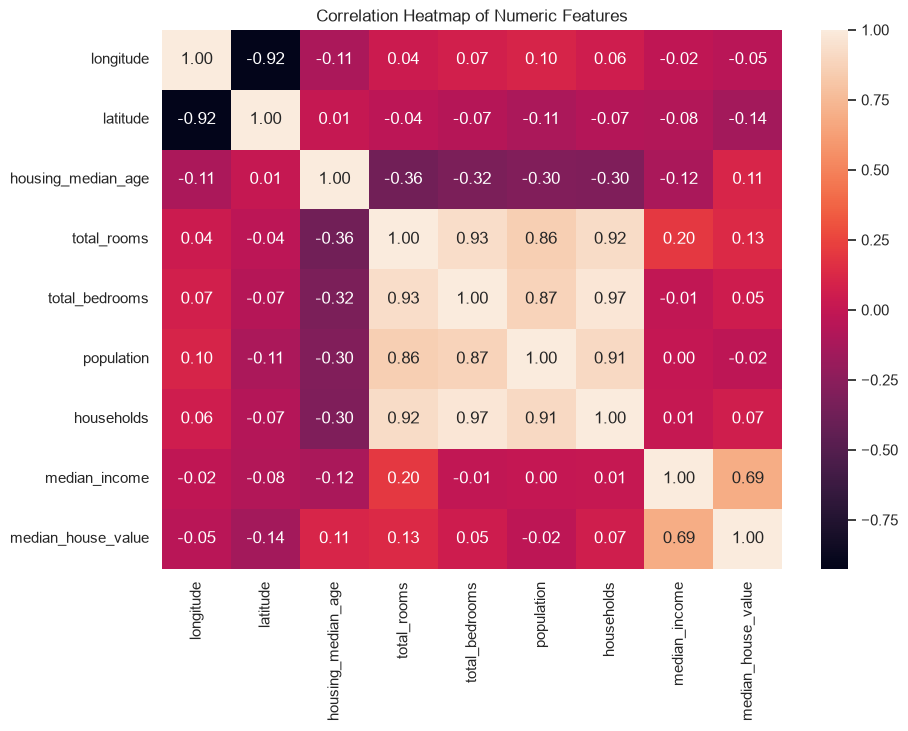

In [18]:
numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt="0.2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

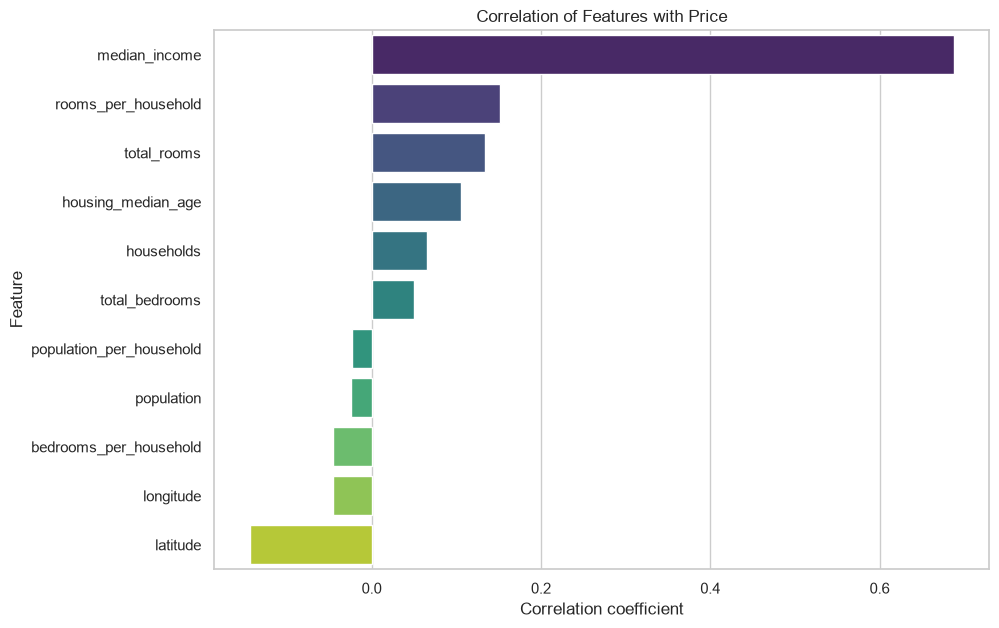

In [19]:
corr = df.corr(numeric_only=True)

price_value = corr['median_house_value'].sort_values(ascending=False)
price_value = price_value.drop('median_house_value')

plt.figure(figsize=(10, 7))
sns.barplot(
    x=price_value.values,
    y=price_value.index,
    hue=price_value.index,
    palette='viridis',
    legend=False
)
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.show()

## Conclusion: 

* `median_income` has a massive positive correlation (~0.68). It is by far the strongest linear predictor of house value. The negative correlations for `latitude` and `longitude` are perfectly describe California's layout:
    * **Latitude (North-South):** As latitude increases (moving further North, past the Bay Area and into deep rural territory), property values generally drop.
    * **Longitude (East-West):** Moving East away from the Pacific Ocean means entering the significantly cheaper inland agricultural and desert regions.


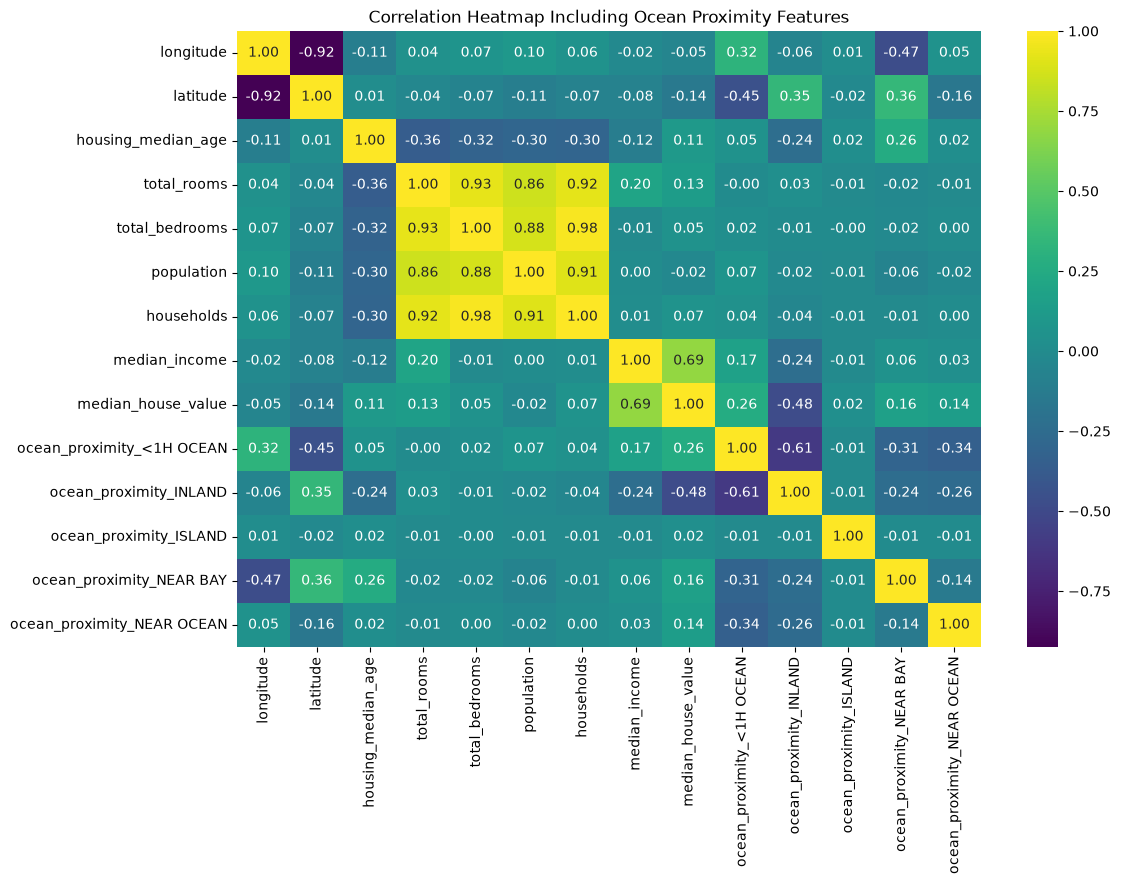

In [17]:
# Convert categorical text into numerical columns (0 and 1)
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

# Set up the visual space (slightly larger to accommodate the new columns)
plt.figure(figsize=(12, 8))

# Generate the heatmap directly on the encoded dataframe
sns.heatmap(df_encoded.corr(), annot=True, fmt="0.2f", cmap="viridis")

plt.title('Correlation Heatmap Including Ocean Proximity Features')
plt.show()


## Conclusions

1. Latitude vs Longitude (~-0.92)
- Strong negative correlation. This reflects the geographic shape of California, which is tilted from northwest to southeast. As we move south, latitude decreases, and as we move toward the interior of the continent, longitude increases. So a city in the north of the state will have coordinates negatively correlated with one in the south.

2. median_house_value vs longitude (~-0.05) and vs latitude (~-0.14)
- Very weak correlations. This tells us that the raw geographic position alone does not directly predict the house price. What matters more is the proximity to the ocean (INLAND / <1H OCEAN), not the raw coordinates.

3. median_house_value vs NEAR OCEAN (~0.14) and vs NEAR BAY (~0.16)
- Weak positive correlations. Prices tend to be a bit higher near the ocean or bay, but the effect is smaller than expected. Interestingly, <1H OCEAN has a stronger effect (~0.26), probably because it includes the big urban areas like San Francisco Bay and LA, where wealthy neighborhoods are concentrated.

4. median_house_value vs ISLAND (very small value)
- The correlation is small not because the price does not increase on islands, but because there are very few examples of island properties in the dataset. The sample size is too small to draw a statistically meaningful conclusion.

5. median_house_value vs INLAND (~-0.48) and vs <1H OCEAN (~0.26)
- INLAND has a strong negative correlation with price. It makes sense: the deeper we go into the continent, the lower the prices. Meanwhile <1H OCEAN has a positive correlation because that is where most of the wealthy neighborhoods are located.

6. median_house_value vs median_income (~0.69)
- Strong positive correlation. Where people earn more, house prices are higher. This is the strongest predictor of house value in the entire dataset, which makes sense: purchasing power directly drives what people can afford.

7. households vs total_bedrooms (~0.98), households vs population (~0.91), total_bedrooms vs total_rooms (~0.93)
- Very strong positive correlations between these features. This is expected: more households means more people, more rooms, more bedrooms. But it also means we have multicollinearity in the dataset, which can be a problem for linear models. A possible fix would be feature engineering, for example creating rooms_per_household = total_rooms / households.

## Feature engineering: derived ratios

The raw counts (`total_rooms`, `total_bedrooms`, `population`, `households`) are all mutually correlated at ~0.9+, which hurts linear models. We replace their information with four ratios that carry the *same signal* but are far less correlated with each other:

* `rooms_per_household` = average size of a housing unit in the block group.
* `bedrooms_per_room` = luxury vs density proxy. Low ratio (~0.15) means many living rooms / kitchens / offices (luxury). High ratio (~0.30+) means almost every room is a bedroom (crowded apartments).
* `population_per_household` = crowding — how many people share a home.
* `income_per_person` = `median_income / population_per_household`. The dataset gives income **per household**, not per person, so this converts it into true purchasing power per individual.


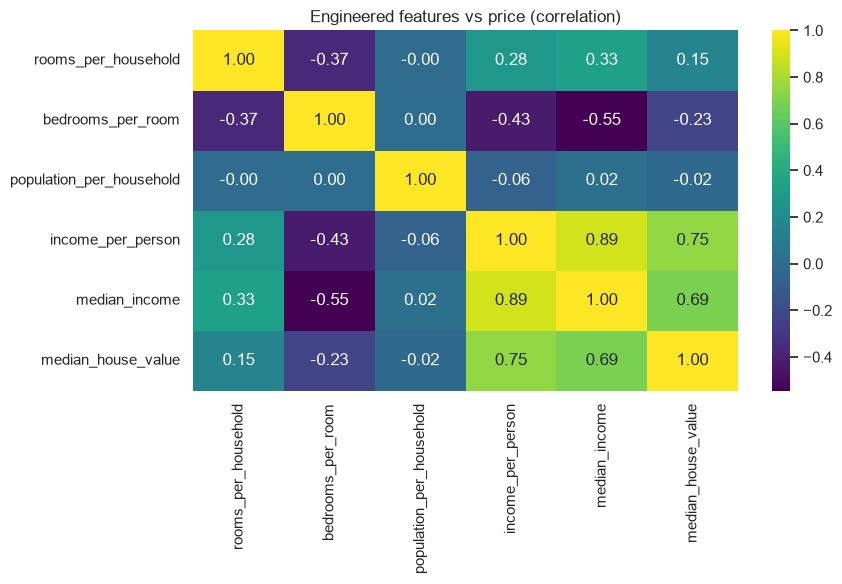

In [ ]:
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['income_per_person'] = df['median_income'] / df['population_per_household']

engineered = [
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'income_per_person',
    'median_income',            
    'median_house_value',
]

plt.figure(figsize=(9, 6))
sns.heatmap(df[engineered].corr(), annot=True, fmt='.2f', cmap='viridis')
plt.title('Engineered features vs price (correlation)')
plt.tight_layout()
plt.show()

## Random Forest — dataset preparation


In [27]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

df_model = df.copy()

df_model['rooms_per_household']      = df_model['total_rooms']    / df_model['households']
df_model['bedrooms_per_room']        = df_model['total_bedrooms'] / df_model['total_rooms']
df_model['population_per_household'] = df_model['population']     / df_model['households']
df_model['income_per_person']        = df_model['median_income']  / df_model['population_per_household']

coastal_metros = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
}
lon = df_model['longitude'].values
lat = df_model['latitude'].values
dists = np.stack(
    [np.sqrt((lon - clon) ** 2 + (lat - clat) ** 2) for clon, clat in coastal_metros.values()],
    axis=0,
)
df_model['dist_to_coastal_metro'] = dists.min(axis=0)

df_model = df_model[df_model['median_house_value'] < 500001]
df_model = df_model[df_model['rooms_per_household']      < 15]
df_model = df_model[df_model['population_per_household'] < 10]
df_model = df_model.reset_index(drop=True)

encoder = OrdinalEncoder()
df_model['ocean_proximity'] = encoder.fit_transform(df_model[['ocean_proximity']]).astype(int)
print('ocean_proximity mapping:', dict(enumerate(encoder.categories_[0])))

drop_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'bedrooms_per_household']
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

print(f'Shape after prep: {df_model.shape}')
df_model.head()

ocean_proximity mapping: {0: '<1H OCEAN', 1: 'INLAND', 2: 'ISLAND', 3: 'NEAR BAY', 4: 'NEAR OCEAN'}
Shape after prep: (19536, 10)


,longitude,latitude,housing_median_age,median_house_value,ocean_proximity,population_per_household,rooms_per_household,bedrooms_per_room,income_per_person,dist_to_coastal_metro
0,-122.23,37.88,41.0,452600.0,3,2.555556,6.984127,0.146591,3.257687,0.219545
1,-122.22,37.86,21.0,358500.0,3,2.109842,6.238137,0.155797,3.934608,0.219317
2,-122.24,37.85,52.0,352100.0,3,2.802260,8.288136,0.129516,2.589838,0.196977
3,-122.25,37.85,52.0,341300.0,3,2.547945,5.817352,0.184458,2.214765,0.187883
4,-122.25,37.85,52.0,342200.0,3,2.181467,6.281853,0.172096,1.763125,0.187883


### Baseline Random Forest

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df_model.drop(columns=['median_house_value'])
y = df_model['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f'{"":10} {"TRAIN":>15} {"TEST":>15}')
print(f'{"RMSE ($)":<10} {train_rmse:>15,.0f} {test_rmse:>15,.0f}')
print(f'{"MAE ($)":<10} {train_mae:>15,.0f} {test_mae:>15,.0f}')
print(f'{"R2":<10} {train_r2:>15.4f} {test_r2:>15.4f}')

                     TRAIN            TEST
RMSE ($)            15,930          41,935
MAE ($)             10,240          26,984
R2                  0.9734          0.8183


In [29]:
df_bare = df.copy()
df_bare['ocean_proximity'] = OrdinalEncoder().fit_transform(df_bare[['ocean_proximity']]).astype(int)

X_b = df_bare.drop(columns=['median_house_value'])
y_b = df_bare['median_house_value']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

rf_bare = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_bare.fit(X_train_b, y_train_b)

y_train_pred_b = rf_bare.predict(X_train_b)
y_test_pred_b  = rf_bare.predict(X_test_b)

train_rmse_b = np.sqrt(mean_squared_error(y_train_b, y_train_pred_b))
test_rmse_b  = np.sqrt(mean_squared_error(y_test_b,  y_test_pred_b))
train_mae_b  = mean_absolute_error(y_train_b, y_train_pred_b)
test_mae_b   = mean_absolute_error(y_test_b,  y_test_pred_b)
train_r2_b   = r2_score(y_train_b, y_train_pred_b)
test_r2_b    = r2_score(y_test_b,  y_test_pred_b)

print(f'{"":10} {"TRAIN":>15} {"TEST":>15}')
print(f'{"RMSE ($)":<10} {train_rmse_b:>15,.0f} {test_rmse_b:>15,.0f}')
print(f'{"MAE ($)":<10} {train_mae_b:>15,.0f} {test_mae_b:>15,.0f}')
print(f'{"R2":<10} {train_r2_b:>15.4f} {test_r2_b:>15.4f}')

                     TRAIN            TEST
RMSE ($)            18,332          49,387
MAE ($)             11,682          31,840
R2                  0.9749          0.8139


### Tuning + Cross-Validation

In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5, 1.0],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV RMSE: ${-search.best_score_:,.0f}')

best_rf = search.best_estimator_
y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f'\n{"":10} {"TRAIN":>15} {"TEST":>15}')
print(f'{"RMSE ($)":<10} {train_rmse:>15,.0f} {test_rmse:>15,.0f}')
print(f'{"MAE ($)":<10} {train_mae:>15,.0f} {test_mae:>15,.0f}')
print(f'{"R2":<10} {train_r2:>15.4f} {test_r2:>15.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV RMSE: $42,002

                     TRAIN            TEST
RMSE ($)            15,369          40,956
MAE ($)              9,999          26,569
R2                  0.9752          0.8267
